In [ ]:
## Day 15 - Sklearn Pipelines

What I learned today:
- Pipeline chains scaling + model into one object
- Can never forget to scale — it's built in!
- Pipeline gives same result as manual — just cleaner
- SVC: 67.46% → 82.83% with proper scaling in pipeline
- SVC is now BEST model — most accurate AND most consistent
- StandardScaler better than MinMaxScaler for most models
- Always use Pipeline in production code!

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

print("Day 15 - Sklearn Pipelines!")

Day 15 - Sklearn Pipelines!


In [4]:
df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")

df["Age"] = df["Age"].fillna(df["Age"].mean())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df = df.drop("Cabin", axis=1)
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})

X = df[["Pclass", "Sex", "Age", "Fare", "SibSp", "Parch"]]
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

print("Data ready!")
print("Train:", X_train.shape)
print("Test: ", X_test.shape)

Data ready!
Train: (712, 6)
Test:  (179, 6)


In [5]:
# Build a pipeline with 2 steps:
# Step 1: Scale the data
# Step 2: Train KNeighbors model

knn_pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('model',  KNeighborsClassifier())
])

print("Pipeline created!")
print("Steps inside pipeline:")
for step_name, step_object in knn_pipeline.steps:
    print(f"  {step_name} → {step_object}")

Pipeline created!
Steps inside pipeline:
  scaler → MinMaxScaler()
  model → KNeighborsClassifier()


In [6]:
# Train the pipeline — scales AND trains in one line!
knn_pipeline.fit(X_train, y_train)

# Predict — scales AND predicts in one line!
predictions = knn_pipeline.predict(X_test)

# Check accuracy
accuracy = accuracy_score(y_test, predictions)
print(f"KNeighbors Pipeline Accuracy: {accuracy*100:.2f}%")

KNeighbors Pipeline Accuracy: 79.89%


In [7]:
# Manual way (old way)
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn_manual = KNeighborsClassifier()
knn_manual.fit(X_train_scaled, y_train)
manual_predictions = knn_manual.predict(X_test_scaled)
manual_accuracy = accuracy_score(y_test, manual_predictions)

print(f"Manual approach:   {manual_accuracy*100:.2f}%")
print(f"Pipeline approach: {accuracy*100:.2f}%")
print()
if manual_accuracy == accuracy:
    print("✅ Same result! Pipeline is just cleaner code.")
else:
    print("Different results — let's investigate!")

Manual approach:   79.89%
Pipeline approach: 79.89%

✅ Same result! Pipeline is just cleaner code.


In [8]:
pipelines = {
    "Logistic Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('model',  LogisticRegression(max_iter=1000))
    ]),
    "KNeighbors": Pipeline([
        ('scaler', StandardScaler()),
        ('model',  KNeighborsClassifier())
    ]),
    "SVC": Pipeline([
        ('scaler', StandardScaler()),
        ('model',  SVC(random_state=42))
    ]),
    "Random Forest": Pipeline([
        ('scaler', StandardScaler()),
        ('model',  RandomForestClassifier(random_state=42))
    ])
}

print("All pipelines created!")
for name in pipelines:
    print(f"  {name} pipeline ✅")

All pipelines created!
  Logistic Regression pipeline ✅
  KNeighbors pipeline ✅
  SVC pipeline ✅
  Random Forest pipeline ✅


In [9]:
print("Pipeline Results (Cross Validation 5 fold):")
print("=" * 50)

pipeline_results = {}
for name, pipeline in pipelines.items():
    cv_scores = cross_val_score(pipeline, X, y, cv=5)
    pipeline_results[name] = cv_scores.mean()
    print(f"{name:25} → {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%")

Pipeline Results (Cross Validation 5 fold):
Logistic Regression       → 78.45% ± 2.03%
KNeighbors                → 81.71% ± 2.46%
SVC                       → 82.83% ± 1.69%
Random Forest             → 81.49% ± 4.13%


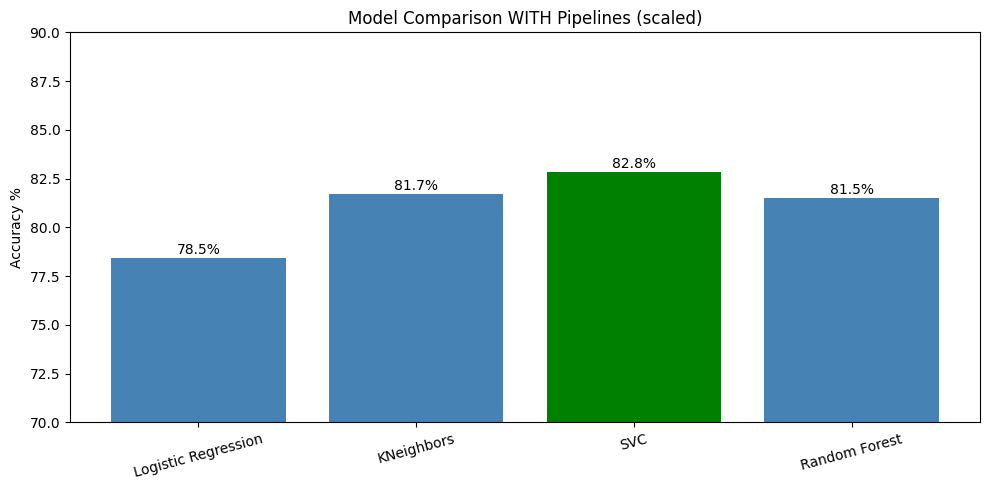

In [10]:
plt.figure(figsize=(10, 5))

names = list(pipeline_results.keys())
scores = [v*100 for v in pipeline_results.values()]
colors = ['green' if v == max(pipeline_results.values()) 
          else 'steelblue' for v in pipeline_results.values()]

plt.bar(names, scores, color=colors)
plt.ylabel("Accuracy %")
plt.title("Model Comparison WITH Pipelines (scaled)")
plt.ylim([70, 90])
plt.xticks(rotation=15)

for i, score in enumerate(scores):
    plt.text(i, score + 0.2, f"{score:.1f}%", 
             ha='center', fontsize=10)

plt.tight_layout()
plt.show()